In [2]:
import torch
from gsnn.models.GSNN import GSNN
from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
import pandas as pd
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt
from gsnn_mds.data.AMLDataset import AMLDataset

from gsnn.interpret.CounterfactualExplainer import CounterfactualExplainer 
from gsnn.interpret.ContrastiveOcclusionExplainer import ContrastiveOcclusionExplainer
from gsnn.interpret.utils import plot_edge_importance
from gsnn.interpret.NoiseTunnel import NoiseTunnel 

import seaborn as sbn 
from pypath.utils import mapping

%load_ext autoreload
%autoreload 2 


In [3]:
def create_input_mapping(inputs_df, data):
    """Create mapping from patient IDs to input vectors.
    
    Note: inputs_df is ordered identically to data.node_names_dict['input']
    and can be directly converted into the input tensor.
    """
    print("Creating input mapping...")
    
    id2x = {}
    
    # Verify that inputs_df columns match the input node names
    input_nodes = data.node_names_dict['input']
    
    # Reorder inputs_df columns to match the order of input nodes
    inputs_df_ordered = inputs_df[input_nodes]
    
    # Convert each row to input tensor directly
    for sample_id, row in inputs_df_ordered.iterrows():
        x = torch.tensor(row.values.astype(np.float32), dtype=torch.float32)
        id2x[sample_id] = x
    
    print(f"Created input mapping for {len(id2x)} patients")
    return id2x

In [4]:
model = torch.load('../../workflow_outputs/gsnn-mds/exp/default/gsnn/gsnn_model.pt', weights_only=False)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.eval() 
model = model.to(device) 

batch_size = 256


In [6]:
data = torch.load('../../workflow_outputs/gsnn-mds/exp/default/graph/graph.pt', weights_only=False)

inputs_df = pd.read_csv('../../workflow_outputs/gsnn-mds/exp/default/graph/inputs.csv')
inputs_df = inputs_df[lambda x: x.id.str.startswith('M')] # MLL-XXX or MUC-xxx

id2x = create_input_mapping(inputs_df.set_index('id'), data)
ids = list(id2x.keys()) 

drug_inputs = [x.split('__')[1] for x in data.node_names_dict['input'] if x.split('__')[0] == 'DRUG']





Creating input mapping...
Created input mapping for 668 patients


In [7]:
inhibitor = ['trametinib (gsk1120212)'] #['gw-2580'] #['gw-2580 + otx-015']
response = 0 

synth_drug = pd.DataFrame({'id': ids, 'partition': 'infer', 'response': response, 'inhibitor': inhibitor*len(ids)})

synth_drug = synth_drug.assign(inhibitor_1 = [x.split(' + ')[0] for x in inhibitor*len(ids)])

#synth_drug = synth_drug.assign(inhibitor_2 = [x.split(' + ')[1] for x in inhibitor*len(ids)])
synth_drug = synth_drug.assign(inhibitor_2 = None) 

synth_drug.head() 

,id,partition,response,inhibitor,inhibitor_1,inhibitor_2
0,MLL_00003,infer,0,trametinib (gsk1120212),trametinib (gsk1120212),None
1,MLL_00009,infer,0,trametinib (gsk1120212),trametinib (gsk1120212),None
2,MLL_09939,infer,0,trametinib (gsk1120212),trametinib (gsk1120212),None
3,MLL_09941,infer,0,trametinib (gsk1120212),trametinib (gsk1120212),None
4,MLL_09942,infer,0,trametinib (gsk1120212),trametinib (gsk1120212),None


In [7]:
pred_dataset = AMLDataset(id2x, synth_drug, data.node_names_dict['input'])
pred_loader = torch.utils.data.DataLoader(pred_dataset, batch_size=256, shuffle=False) 

print(f'Number of predictions: {len(pred_dataset)}')

Number of predictions: 668


In [8]:
yhat = [] 
xs = [] 

with torch.no_grad(): 
    for x, _ in pred_loader:
        xs.append(x.cpu()) 
        x = x.to(device) 
        yhat.append(model(x).cpu()) 

yhat = torch.cat(yhat, axis=0) 
xs = torch.cat(xs, axis=0) 

yhat = yhat.reshape(-1) 

synth_drug = synth_drug.assign(yhat = yhat) 
synth_drug.head() 

,id,partition,response,inhibitor,inhibitor_1,inhibitor_2,yhat
0,MLL_00003,infer,0,venetoclax,venetoclax,None,-0.559240
1,MLL_00009,infer,0,venetoclax,venetoclax,None,-0.798136
2,MLL_09939,infer,0,venetoclax,venetoclax,None,-0.675215
3,MLL_09941,infer,0,venetoclax,venetoclax,None,-0.848056
4,MLL_09942,infer,0,venetoclax,venetoclax,None,-1.001566


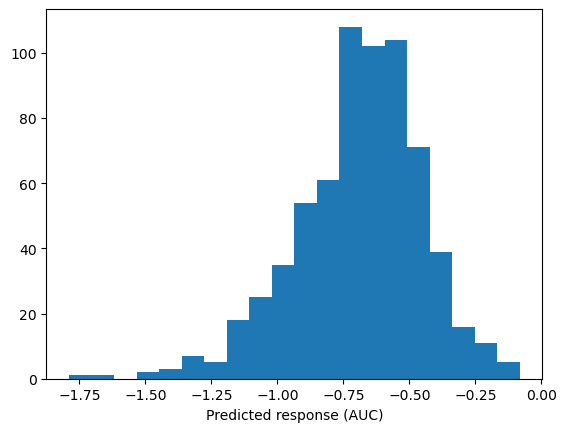

In [9]:
plt.figure() 
plt.hist(synth_drug.yhat, bins=20) 
plt.xlabel('Predicted response (AUC)') 
plt.show() 

In [10]:
y_res = synth_drug.sort_values('yhat', ascending=False).head(1) 
y_sens= synth_drug.sort_values('yhat', ascending=True).head(1) 

x_res = xs[y_res.index.values[0]]
x_sens = xs[y_sens.index.values[0]] 

print('y res value: ', y_res.yhat.values[0])
print('y sens value: ', y_sens.yhat.values[0])


y res value:  -0.08147631
y sens value:  -1.7897909


In [11]:
torch.cuda.empty_cache() 

explainer = NoiseTunnel(ContrastiveIGExplainer(model, data, n_steps=50))
ig_res = explainer.explain(x_res, x_sens, target_idx=0)

ig_res.sort_values('score', ascending=False).head(10)


,source,target,score
98990,EXPR__P18754,PROTEIN__P18754,0.029830
45412,PROTEIN__Q07817,PROTEIN__P04637,0.027558
96194,DRUG__venetoclax,PROTEIN__P10415,0.019286
98618,EXPR__Q14493,PROTEIN__Q14493,0.016937
102444,PROTEIN__Q6IWH7,PROTEIN__Q6IWH7,0.015453
20953,PROTEIN__P04637,PROTEIN__Q86Y07,0.014196
10377,PROTEIN__P10415,PROTEIN__P61278,0.013627
10372,PROTEIN__P10415,PROTEIN__P09874,0.013227
98331,EXPR__P42574,PROTEIN__P42574,0.013059
102731,PROTEIN__O43913,PROTEIN__O43913,0.012849


In [12]:
ig_res[lambda x: x.source.str.contains('PATHWAY__')].sort_values('score', ascending=False).head(20).style.hide()

source,target,score
PATHWAY__Mitochondrial protein degradation,OUT_AUC,0.010612
"PATHWAY__BMAL1:CLOCK,NPAS2 activates circadian expression",OUT_AUC,0.009047
PATHWAY__Constitutive Signaling by Aberrant PI3K in Cancer,OUT_AUC,0.008607
PATHWAY__Deposition of new CENPA-containing nucleosomes at the centromere,OUT_AUC,0.008076
PATHWAY__G2/M Checkpoints,OUT_AUC,0.007577
PATHWAY__Proteasome assembly,OUT_AUC,0.006815
PATHWAY__Viral Messenger RNA Synthesis,OUT_AUC,0.006789
PATHWAY__Estrogen-dependent gene expression,OUT_AUC,0.006401
PATHWAY__GLI3 is processed to GLI3R by the proteasome,OUT_AUC,0.006131
PATHWAY__G1/S-Specific Transcription,OUT_AUC,0.006051


In [13]:
ig_res.sort_values('score', ascending=False)[lambda x: x.source.str.contains('EXPR__')].head(10).style.hide()


source,target,score
EXPR__P18754,PROTEIN__P18754,0.029830
EXPR__Q14493,PROTEIN__Q14493,0.016937
EXPR__P42574,PROTEIN__P42574,0.013059
EXPR__O00232,PROTEIN__O00232,0.012493
EXPR__O00141,PROTEIN__O00141,0.011664
EXPR__Q99436,PROTEIN__Q99436,0.011630
EXPR__O14980,PROTEIN__O14980,0.011470
EXPR__P27986,PROTEIN__P27986,0.011201
EXPR__P06239,PROTEIN__P06239,0.010890
EXPR__P05771,PROTEIN__P05771,0.009550


In [14]:
ig_res.sort_values('score', ascending=False)[lambda x: x.source.str.contains('MUT__')].head(10).style.hide()


source,target,score
MUT__P10721,PROTEIN__P10721,0.000912
MUT__P01111,PROTEIN__P01111,0.000119
MUT__O60216,PROTEIN__O60216,0.000061
MUT__Q15022,PROTEIN__Q15022,0.000037
MUT__Q06124,PROTEIN__Q06124,0.000031
MUT__Q15910,PROTEIN__Q15910,0.000018
MUT__P21359,PROTEIN__P21359,0.000010
MUT__P40238,PROTEIN__P40238,0.000007
MUT__Q9Y6K1,PROTEIN__Q9Y6K1,0.000006
MUT__P48735,PROTEIN__P48735,0.000006


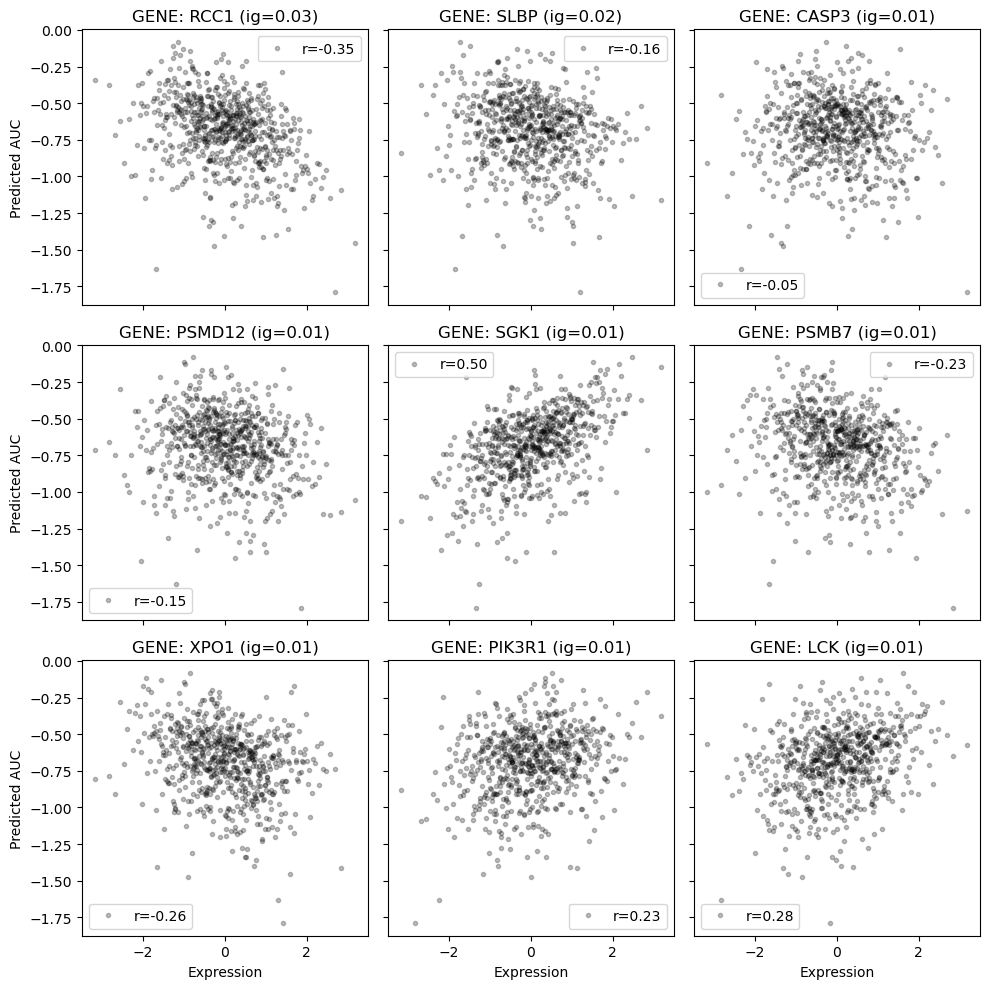

In [15]:
biomarker_candidates = ig_res.sort_values('score', ascending=False)[lambda x: x.source.str.contains('EXPR__')].head(9)

f, axes = plt.subplots(3, 3, figsize=(10, 10), sharex=True, sharey=True) 

for i, (ax, (j,row)) in enumerate(zip(axes.flatten(), biomarker_candidates.iterrows())): 
    uniprot = row.source.split('__')[1]

    gene_symbol = mapping.map_name(uniprot, 'uniprot', 'genesymbol')

    if len(gene_symbol) == 0: 
        name = uniprot
    else: 
        name = gene_symbol.pop()

    r = np.corrcoef(xs[:, data.node_names_dict['input'].index(row.source)].detach().cpu().numpy(), synth_drug.yhat.values)[0,1]
    ax.plot(xs[:, data.node_names_dict['input'].index(row.source)].detach().cpu().numpy(), synth_drug.yhat.values, 'k.', alpha=0.25, label=f'r={r:.2f}') 
    ax.set_title(f'GENE: {name} (ig={row.score:.2f})') 
    ax.legend() 
    #tmp = synth_drug.copy().assign(expr=xs[:, data.node_names_dict['input'].index(row.source)].detach().cpu().numpy())
    #sbn.regplot(x='expr', y='yhat', data=tmp, ax=ax, scatter=False, color='r', label=None, ) 

axes[0,0].set_ylabel('Predicted AUC') 
axes[1,0].set_ylabel('Predicted AUC')
axes[2,0].set_ylabel('Predicted AUC')
axes[2,0].set_xlabel('Expression') 
axes[2,1].set_xlabel('Expression') 
axes[2,2].set_xlabel('Expression') 

plt.tight_layout() 
plt.show() 

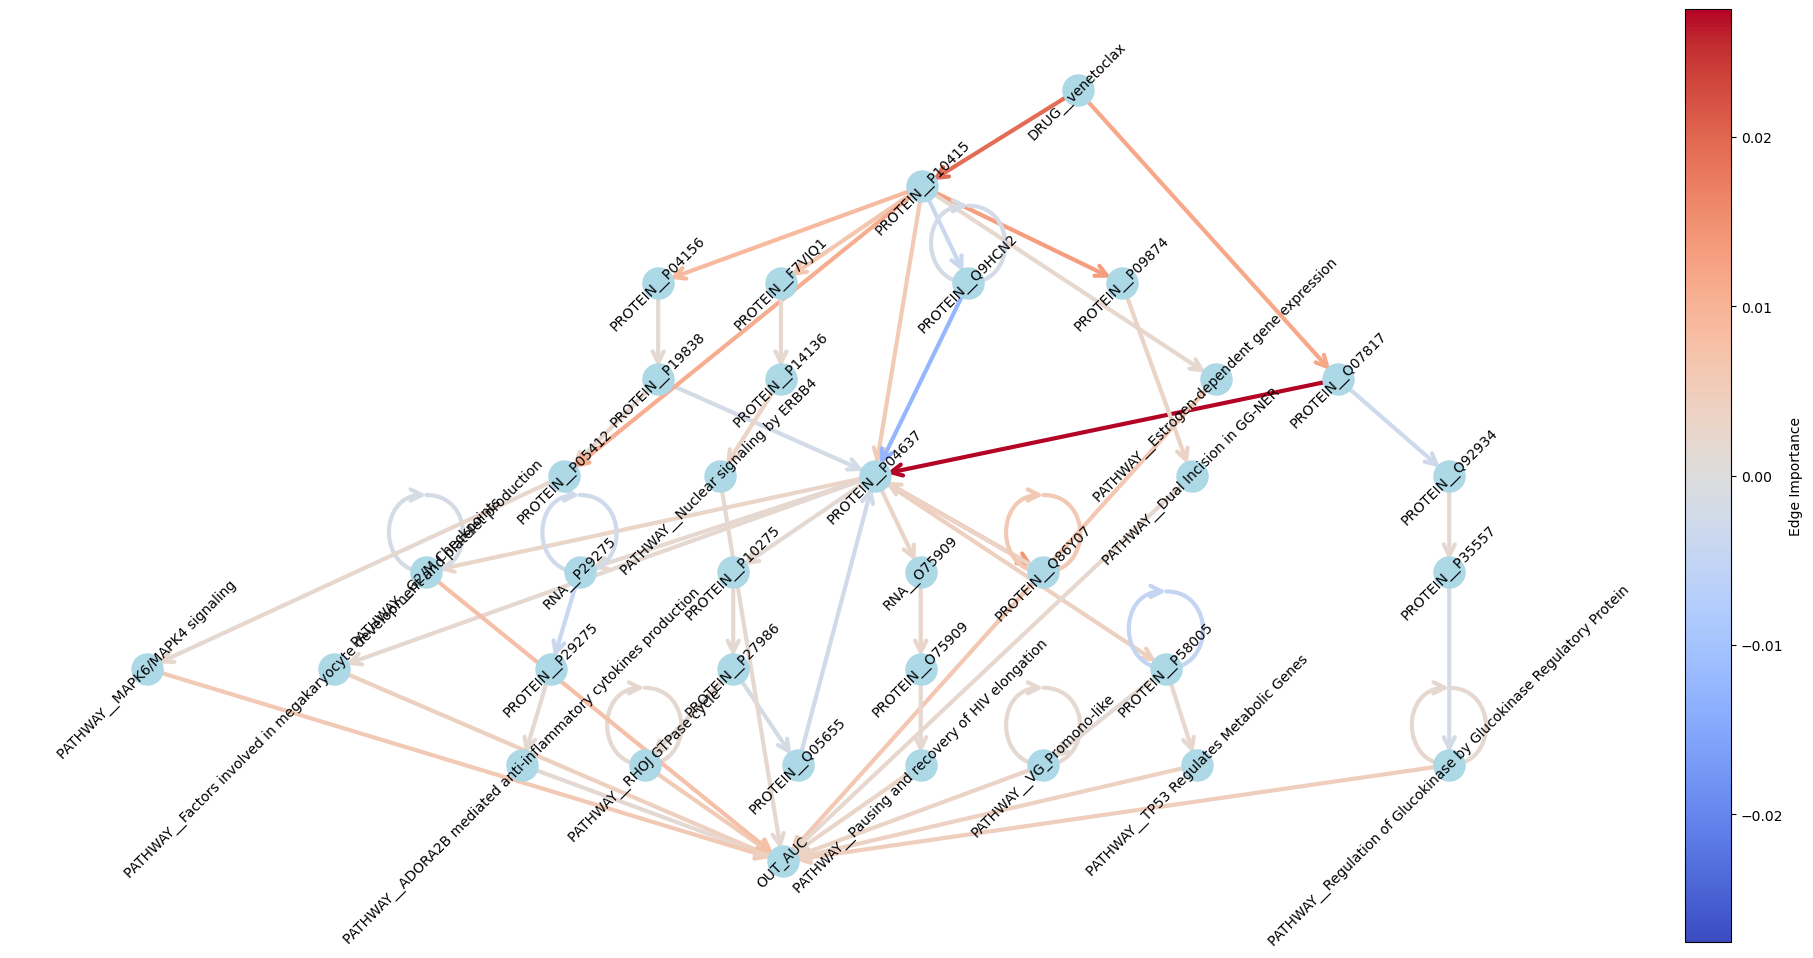

In [16]:
t = ig_res.sort_values('score', ascending=False).score.values[1000]
plot_edge_importance(ig_res[lambda x: x.score.abs() > t], figsize=(20,10), leafs=['OUT_AUC'], roots=['DRUG__venetoclax'])

In [17]:
# TODO: include cell type like gene sets (?)
# MUT only graph vs EXPR only graph 
# can we improve ven preds 


# Counterfactual explanations 

In [18]:
cf_explainer = CounterfactualExplainer(model, data) 

# we will only optimize non-drug inputs to look for sensitivity predictors 
trainable_mask = torch.tensor(['DRUG__' not in x for x in data.node_names_dict['input']], dtype=torch.bool)

res = cf_explainer.explain(x_res.view(1, -1), target_idx=0, target_value=-0.5, trainable_mask=trainable_mask, 
                            lr=1e-4, dropout=0.5, weight_decay=1)

print(res.attrs)
 
res.sort_values('perturbation', ascending=False)

Iteration 90: Loss = 0.156453
Converged at iteration 90
Final loss: 0.156453
{'converged_loss': 0.15645308792591095, 'iterations': 91, 'batch_size': 1, 'original_prediction': array([[-0.08147711]], dtype=float32), 'final_prediction': array([[-0.10570388]], dtype=float32), 'target_value': array([[-0.5]], dtype=float32)}


,feature,original,perturbation,counterfactual
1608,MUT__P19544,0.000000,0.006709,0.006709
1617,MUT__Q76L83,0.000000,0.006436,0.006436
243,EXPR__P61978,-0.746535,0.006384,-0.740152
123,EXPR__Q06945,-0.513483,0.006383,-0.507100
34,EXPR__P01911,1.536357,0.006311,1.542668
...,...,...,...,...
1491,EXPR__P08069,0.317192,-0.006045,0.311147
167,EXPR__P14625,-1.436693,-0.006085,-1.442778
502,EXPR__P20701,2.028986,-0.006089,2.022897
1618,MUT__P01116,0.000000,-0.006118,-0.006118


In [19]:
res.perturbation.abs().sum() 

np.float32(3.5904741)

In [20]:
torch.cuda.empty_cache() 

In [21]:
# now contrastive ig to see what latent vars are driving the difference 
x_res2 = torch.tensor(res.counterfactual.values, dtype=torch.float32).view(1, -1)

c_explainer = NoiseTunnel(ContrastiveIGExplainer(model, data, n_steps=50), n_samples=10)
#c_explainer = ContrastiveOcclusionExplainer(model, data, verbose=True) 

res_c = c_explainer.explain(x_res.view(1, -1), x_res2, target_idx=0)

res_c.sort_values('score', ascending=False)

,source,target,score
10385,PROTEIN__P10415,PROTEIN__P05412,0.000142
45412,PROTEIN__Q07817,PROTEIN__P04637,0.000110
104634,PROTEIN__Q76L83,PROTEIN__Q76L83,0.000101
99658,EXPR__Q9H0E9,PROTEIN__Q9H0E9,0.000082
99709,MUT__Q76L83,PROTEIN__Q76L83,0.000080
...,...,...,...
98853,EXPR__Q12913,PROTEIN__Q12913,-0.000049
22773,PROTEIN__Q9HCN2,PROTEIN__P04637,-0.000056
71420,PROTEIN__Q9H0E9,PROTEIN__P37231,-0.000065
105830,PROTEIN__Q01167,PROTEIN__Q01167,-0.000079


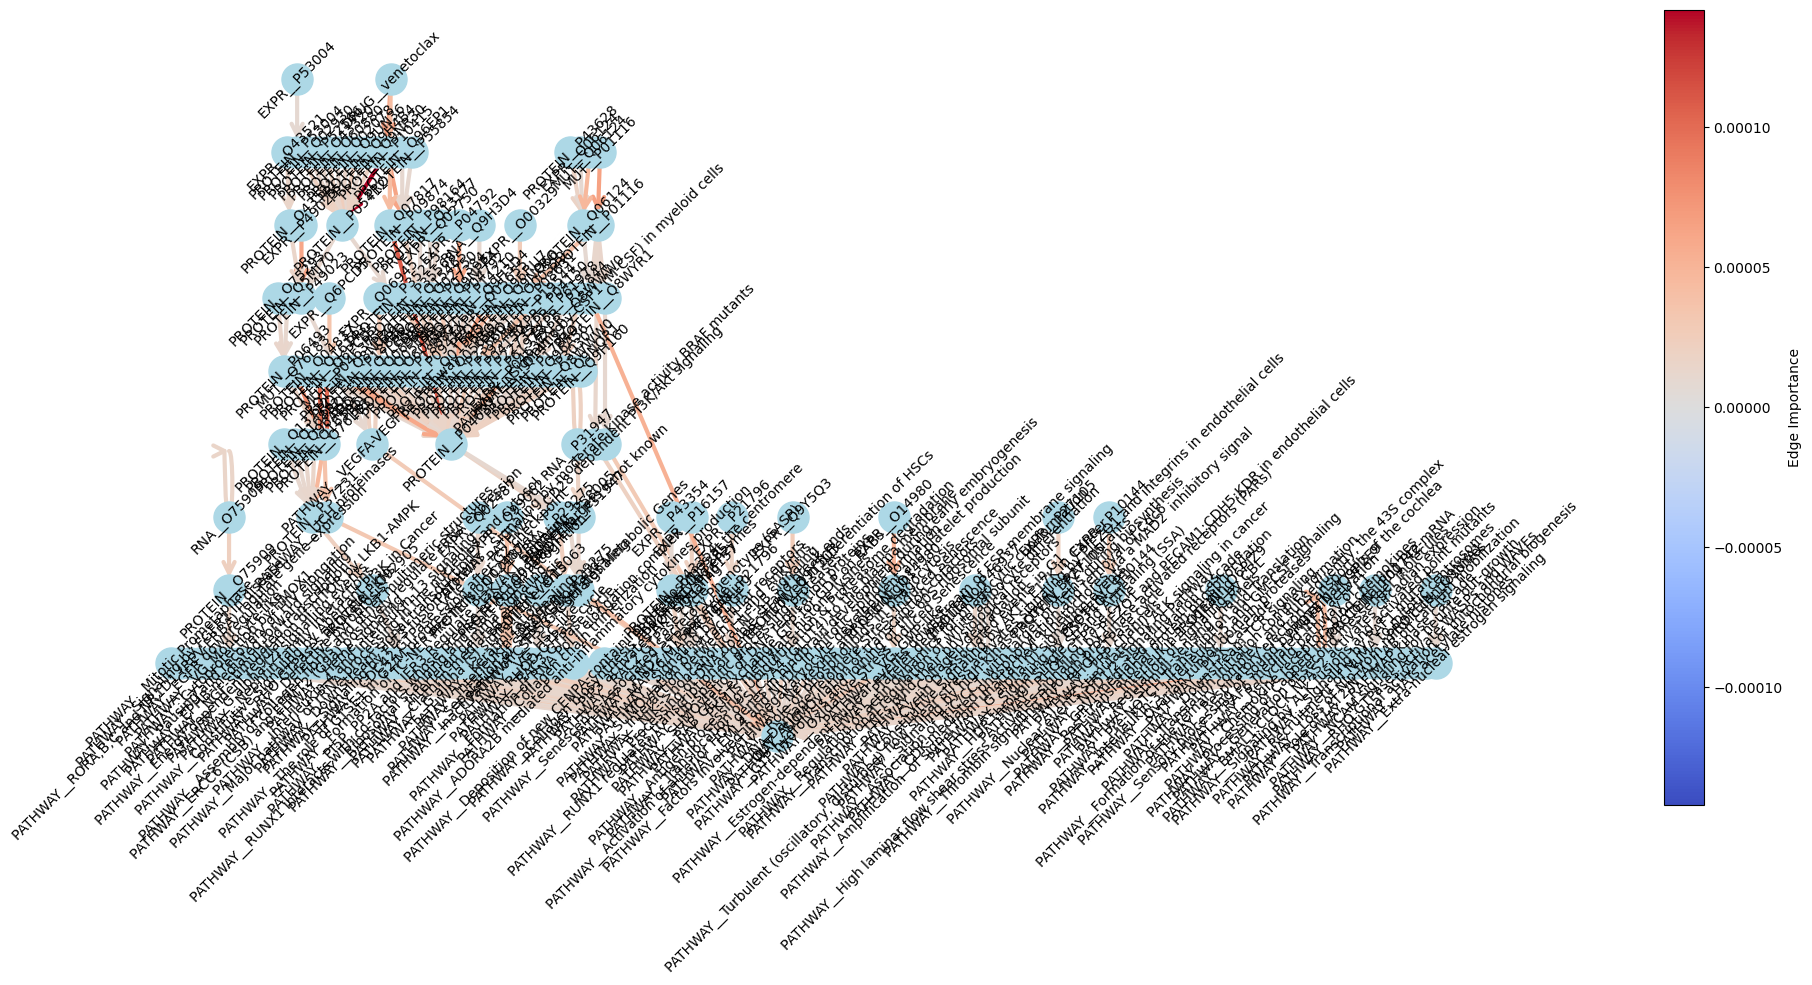

In [22]:
t = res_c.sort_values('score', ascending=False).score.values[700]
plot_edge_importance(res_c[lambda x: x.score > t], figsize=(20,10), leafs=['OUT_AUC']) #, roots=['DRUG__venetoclax'])

# Try a slightly different approach... 

for the top N most resistant patients, can we find an counterfactual example that increases sensitivity? 

In [23]:
x_res_batch = xs[synth_drug.sort_values('yhat', ascending=False).head(5).index.values]
print(x_res_batch.shape)

cf_explainer = CounterfactualExplainer(model, data) 

# we will only optimize non-drug inputs to look for sensitivity predictors 
trainable_mask = torch.tensor(['DRUG__' not in x for x in data.node_names_dict['input']], dtype=torch.bool)

res = cf_explainer.explain(x_res_batch, target_idx=0, target_value=-1, trainable_mask=trainable_mask, 
                            lr=1e-3, dropout=0., weight_decay=1e-1)

 
res.sort_values('perturbation', ascending=False)

torch.Size([5, 1756])


,feature,original,perturbation,counterfactual
1598,MUT__P21359,0.000000,0.497864,0.497864
1608,MUT__P19544,0.000000,0.466323,0.466323
243,EXPR__P61978,-0.115386,0.214788,0.099403
1239,EXPR__P25490,-0.724480,0.206561,-0.517919
346,EXPR__Q05655,0.863471,0.184128,1.047599
...,...,...,...,...
1600,MUT__P04637,0.000000,-0.300005,-0.300005
1418,EXPR__Q6PCD5,-0.686824,-0.322119,-1.008943
1613,MUT__Q06124,0.000000,-0.362205,-0.362205
725,EXPR__Q13045,0.450756,-0.392310,0.058445


In [24]:
xs = xs.cuda() 

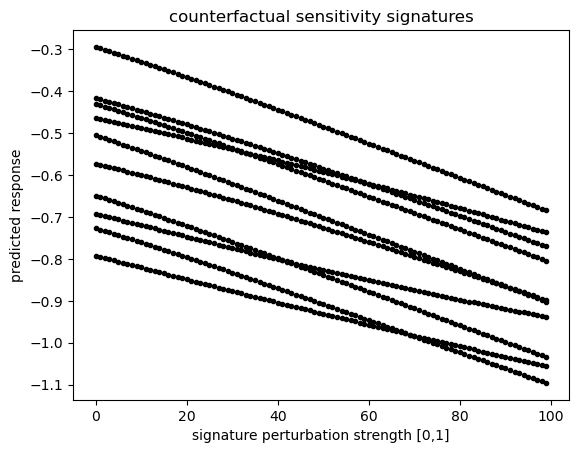

In [25]:
# choose some other random patients 
x_batch = xs[synth_drug.sample(30).index.values]

x_sig = torch.tensor(res.perturbation.values, dtype=torch.float32).view(1, -1).cuda()

plt.figure() 

for i in range(10): 
    xxx = x_batch[[i]].expand(100, -1) + x_sig.expand(100, -1)*torch.linspace(0, 1, 100).view(100, 1).cuda() 
    with torch.no_grad(): yhat = model(xxx).detach().cpu().numpy() 

    plt.plot(yhat, 'k.') 

plt.xlabel('signature perturbation strength [0,1]')
plt.ylabel('predicted response')
plt.title('counterfactual sensitivity signatures')

plt.show() 

## Try counterfactuals with drugs, look for combos 

In [26]:
torch.cuda.empty_cache() 

In [ ]:
#x_res_batch = xs[synth_drug.sort_values('yhat', ascending=False).head(100).index.values]
from matplotlib.pyplot import xscale


device = 'cuda' if torch.cuda.is_available() else 'cpu'

drug_ixs = torch.tensor([i for i,n in enumerate(data.node_names_dict['input']) if 'DRUG__' in n], dtype=torch.long)

x_drug_prob = torch.zeros(1, drug_ixs.shape[0], device=device, requires_grad=True)  

optim = torch.optim.Adam([x_drug_prob], lr=1e-2) 

batch_size = 32

losses = [] 
for i in range(1000): 
    optim.zero_grad() 
    x_drug = torch.nn.functional.gumbel_softmax(x_drug_prob, dim=-1, hard=False, tau=3)  
    batch_ixs = torch.randint(0, xs.shape[0], (batch_size,))
    xx = xs.clone()[batch_ixs]
    xx[:, drug_ixs] = x_drug
    yhat = model(xx.to(device)) 
    loss = yhat.mean() 
    loss.backward() 
    optim.step() 
    print(i, loss.item(), end='\r') 
    losses.append(loss.item()) 

drug_comb_res = pd.DataFrame({'inhibitor':np.array(data.node_names_dict['input'])[drug_ixs], 'prob':x_drug_prob.softmax(dim=-1).detach().cpu().numpy().flatten()})

In [35]:
drug_comb_res = pd.DataFrame({'inhibitor':np.array(data.node_names_dict['input'])[drug_ixs], 'prob':x_drug_prob.softmax(dim=-1).detach().cpu().numpy().flatten()})
drug_comb_res.sort_values('prob', ascending=False).head(10)

,inhibitor,prob
92,DRUG__sns-032 (bms-387032),0.465151
105,DRUG__foretinib (xl880),0.415704
52,DRUG__ink-128,0.045568
90,DRUG__venetoclax,0.043752
25,DRUG__dasatinib,0.012484
60,DRUG__pi-103,0.005866
120,DRUG__otx-015,0.003650
68,DRUG__panobinostat,0.003034
107,DRUG__selinexor,0.002225
48,DRUG__at7519,0.000615


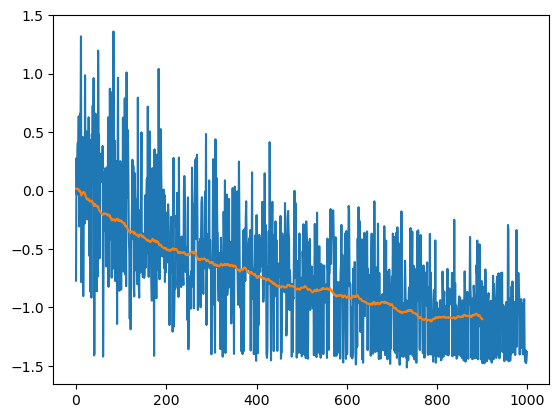

In [36]:
plt.figure() 
plt.plot(losses) 
# running mean 
plt.plot(np.convolve(losses, np.ones(100)/100, mode='valid')) 
plt.show() 

In [37]:
# TODO: filter to high performance drugs 

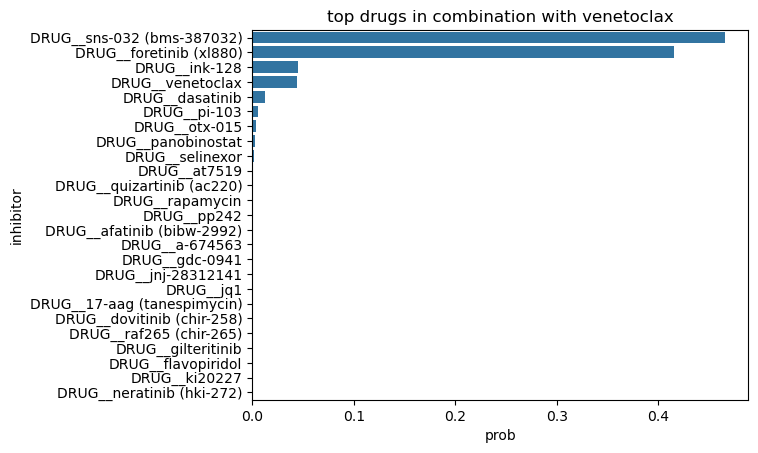

In [ ]:
plt.figure() 
sbn.barplot(y='inhibitor', x='prob', orient='h', data=drug_comb_res.sort_values('prob', ascending=False).head(10)) 

plt.title('top drugs in combination with venetoclax')
plt.show() 

In [32]:
#Combination venetoclax and selinexor effective in relapsed refractory multiple myeloma with translocation t(11;14) - https://pmc.ncbi.nlm.nih.gov/articles/PMC9581939/

In [ ]:
# can we explain why drug A + ven is synergistic? 

# compare ven vs ven + drug A , explain difference 